# Pipeline Setup 

Taken from separate files to allow for a single notebook to run without path issues.

In [1]:
import re
import tqdm
import string
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

## config.py

In [2]:
from dataclasses import dataclass
from pathlib import Path
from typing import Literal, Optional

@dataclass
class CorpusConfig:
    corpus_name: str
    source_type: Literal["local_file", "url"]
    source: str

    vocab_size: int = 4096
    sequence_length: int = 10
    window_size: int = 2
    num_negative_samples: int = 4
    embedding_dim: int = 128
    batch_size: int = 1024
    buffer_size: int = 10000
    epochs: int = 20
    seed: int = 42

    lowercase: bool = True
    strip_punctuation: bool = False
    keep_apostrophes: bool = True
    min_line_length: int = 1
    max_lines: Optional[int] = None #cuts the expensive outer loop before skip-gram generation starts.

## preprocessing.py

In [3]:

# Generates skip-gram pairs with negative sampling for a list of sequences
# (int-encoded sentences) based on window size, number of negative samples
# and vocabulary size.
def generate_training_data(sequences, window_size, num_ns, vocab_size, seed):

  # Set the random seed for reproducibility.
  seed = 42 if seed is None else int(seed)

  # Elements of each training example are appended to these lists.
  targets, contexts, labels = [], [], []

  # Build the sampling table for `vocab_size` tokens.
  sampling_table = tf.keras.preprocessing.sequence.make_sampling_table(vocab_size)

  # Iterate over all sequences (sentences) in the dataset.
  for sequence in tqdm.tqdm(sequences):

    # Generate positive skip-gram pairs for a sequence (sentence).
    positive_skip_grams, _ = tf.keras.preprocessing.sequence.skipgrams(
          sequence,
          vocabulary_size=vocab_size,
          sampling_table=sampling_table,
          window_size=window_size,
          negative_samples=0,
          # skips Keras's internal shuffling of skip-gram pairs, which is not needed as we will shuffle later on in `tf.data.Dataset.shuffle(10000)` plus there was a potential issue with seed being treated as a float but failing as it expects an int.
          shuffle=False, 
    )

    # Iterate over each positive skip-gram pair to produce training examples
    # with a positive context word and negative samples.
    for target_word, context_word in positive_skip_grams:
      context_class = tf.expand_dims(
          tf.constant([context_word], dtype="int64"), 1)
      negative_sampling_candidates, _, _ = tf.random.log_uniform_candidate_sampler(
          true_classes=context_class,
          num_true=1,
          num_sampled=num_ns,
          unique=True,
          range_max=vocab_size,
          seed=seed,
          name="negative_sampling")

      # Build context and label vectors (for one target word)
      context = tf.concat([tf.squeeze(context_class,1), negative_sampling_candidates], 0)
      label = tf.constant([1] + [0]*num_ns, dtype="int64")

      # Append each element from the training example to global lists.
      targets.append(target_word)
      contexts.append(context)
      labels.append(label)

  return targets, contexts, labels

def build_standardizer(lowercase=True, strip_punctuation=False, keep_apostrophes=True):
    punctuation = string.punctuation
    if keep_apostrophes:
        punctuation = punctuation.replace("'", "")

    pattern = "[%s]" % re.escape(punctuation)

    def standardize(input_data):
        text = input_data
        if lowercase:
            text = tf.strings.lower(text)
        if strip_punctuation:
            text = tf.strings.regex_replace(text, pattern, "")
        return text

    return standardize

def build_vectorizer(config):
    standardize = build_standardizer(
        lowercase=config.lowercase,
        strip_punctuation=config.strip_punctuation,
        keep_apostrophes=config.keep_apostrophes,
    )

    return layers.TextVectorization(
        standardize=standardize,
        max_tokens=config.vocab_size,
        output_mode="int",
        output_sequence_length=config.sequence_length,
    )

## model.py

In [4]:


class Word2Vec(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.target_embedding = layers.Embedding(
            vocab_size,
            embedding_dim,
            name="w2v_embedding",
        )
        self.context_embedding = layers.Embedding(vocab_size, embedding_dim)

    def call(self, pair):
        target, context = pair
        if len(target.shape) == 2:
            target = tf.squeeze(target, axis=1)

        word_emb = self.target_embedding(target)
        context_emb = self.context_embedding(context)
        dots = tf.einsum("be,bce->bc", word_emb, context_emb)
        return dots

def build_model(vocab_size, embedding_dim):
    model = Word2Vec(vocab_size, embedding_dim)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    return model

## pipeline.py

In [5]:
# import numpy as np
# import tensorflow as tf
# from .model import build_model
# from .preprocessing import build_vectorizer

def load_text_dataset(config):
    if config.source_type == "url":
        local_path = tf.keras.utils.get_file(
            fname=f"{config.corpus_name}.txt",
            origin=config.source,
        )
        path = local_path
    elif config.source_type == "local_file":
        path = config.source
    else:
        raise ValueError(f"Unsupported source_type: {config.source_type}")

    text_ds = tf.data.TextLineDataset(path)
    text_ds = text_ds.filter(lambda x: tf.strings.length(x) >= config.min_line_length)

    if config.max_lines is not None:
        text_ds = text_ds.take(config.max_lines)

    return text_ds, path

def prepare_training_dataset(text_ds, config, generate_training_data):
    autotune = tf.data.AUTOTUNE

    vectorize_layer = build_vectorizer(config)
    vectorize_layer.adapt(text_ds.batch(1024))

    vocab = vectorize_layer.get_vocabulary()
    actual_vocab_size = len(vocab)

    text_vector_ds = (
        text_ds
        .batch(1024)
        .prefetch(autotune)
        .map(vectorize_layer)
        .unbatch()
    )

    sequences = list(text_vector_ds.as_numpy_iterator())

    targets, contexts, labels = generate_training_data(
        sequences=sequences,
        window_size=config.window_size,
        num_ns=config.num_negative_samples,
        vocab_size=actual_vocab_size,
        seed=config.seed,
    )

    targets = np.array(targets)
    contexts = np.array(contexts)
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices(((targets, contexts), labels))
    dataset = dataset.shuffle(config.buffer_size).batch(config.batch_size, drop_remainder=True)
    dataset = dataset.cache().prefetch(buffer_size=autotune)

    return {
        "dataset": dataset,
        "vectorize_layer": vectorize_layer,
        "vocab": vocab,
        "actual_vocab_size": actual_vocab_size,
        "targets": targets,
        "contexts": contexts,
        "labels": labels,
        "sequences": sequences,
    }

def train_word2vec_pipeline(config, generate_training_data):
    text_ds, resolved_path = load_text_dataset(config)

    prepared = prepare_training_dataset(
        text_ds=text_ds,
        config=config,
        generate_training_data=generate_training_data,
    )

    model = build_model(
        vocab_size=prepared["actual_vocab_size"],
        embedding_dim=config.embedding_dim,
    )

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=f"logs/{config.corpus_name}"
    )

    history = model.fit(
        prepared["dataset"],
        epochs=config.epochs,
        callbacks=[tensorboard_callback],
    )

    weights = model.get_layer("w2v_embedding").get_weights()[0]

    return {
        "model": model,
        "history": history,
        "weights": weights,
        "vocab": prepared["vocab"],
        "vectorize_layer": prepared["vectorize_layer"],
        "dataset": prepared["dataset"],
        "source_path": resolved_path,
        "targets": prepared["targets"],
        "contexts": prepared["contexts"],
        "labels": prepared["labels"],
        "sequences": prepared["sequences"],
    }

# Word Embedding Training

In [6]:
# check working directory as it helps to know where the notebook is running and how relative paths will be resolved
import os, sys
print(os.getcwd())
print(sys.path[:5])

/content
['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload']


In [7]:
from pathlib import Path
from datasets import load_dataset

output_path = Path("data/contemporary_corpus.txt")
output_path.parent.mkdir(parents=True, exist_ok=True)

if output_path.exists() and output_path.stat().st_size > 0:
    print(f"Using existing corpus file: {output_path.resolve()}")
else:
    print("Building contemporary_corpus.txt from AG News...")

    dataset = load_dataset("ag_news", split="train")
    first_column_row = dataset.column_names[0]
    print(dataset.column_names)
    print(dataset[0])

    with output_path.open("w", encoding="utf-8") as f:
        for row in dataset:
            text = row[first_column_row].strip()
            if text:
                f.write(text + "\n")

    # Creates at /content/data/contemporary_corpus.txt
    # which is a relative path. So the actual file location depends on the notebook kernel’s current working directory.
    print(f"Created corpus file: {output_path.resolve()}")

Building contemporary_corpus.txt from AG News...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

['text', 'label']
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}
Created corpus file: /content/data/contemporary_corpus.txt


In [8]:
# from config import CorpusConfig
# from pipeline import train_word2vec_pipeline
# from preprocessing import generate_training_data

contemporary_config = CorpusConfig(
    corpus_name="contemporary_news",
    source_type="local_file",
    source="data/contemporary_corpus.txt",
    vocab_size=8000,
    # sequence_length=12,
    # window_size=2,
    # num_negative_samples=4,
    embedding_dim=128,
    batch_size=1024,
    # epochs=20,
    epochs=10,
    # epochs=1,  # for quick testing, but should be increased for better results
    lowercase=True,
    strip_punctuation=False,
    keep_apostrophes=True,
    # controls preprocessing
    sequence_length=5,
    window_size=1,
    num_negative_samples=2,
    min_line_length=20,
    max_lines=23000,
)

shakespeare_config = CorpusConfig(
    corpus_name="shakespeare",
    source_type="url",
    source="https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt",
    vocab_size=4096,
    # sequence_length=10,
    # window_size=2,
    # num_negative_samples=4,
    embedding_dim=128,
    batch_size=1024,
    buffer_size=10000,
    # epochs=20,
    epochs=10,
    # epochs=1,  # for quick testing, but should be increased for better results
    seed=42,
    lowercase=True,
    strip_punctuation=True,
    keep_apostrophes=False,
    # min_line_length=1,
    # controls preprocessing
    sequence_length=5,
    window_size=2,
    num_negative_samples=2,
    min_line_length=20,
)


def print_training_results(config, results):
  word2vec = results["model"]
  w2v_history = results["history"]
  weights = results["weights"]
  vocab = results["vocab"]
  vectorize_layer = results["vectorize_layer"]
  dataset = results["dataset"]
  sequences = results["sequences"]
  targets = results["targets"]
  contexts = results["contexts"]
  labels = results["labels"]

  print(f"Corpus: {config.corpus_name}")
  print(f"Number of sequences: {len(sequences)}")
  print(f"Number of training examples: {len(targets)}")
  print(f"targets.shape: {targets.shape}")
  print(f"contexts.shape: {contexts.shape}")
  print(f"labels.shape: {labels.shape}")
  print(f"Embedding shape: {weights.shape}")
  print(f"First 10 vocab terms: {vocab[:10]}")

In [9]:
shakespeare_results = train_word2vec_pipeline(
    config=shakespeare_config,
    generate_training_data=generate_training_data,
)

contemporary_results = train_word2vec_pipeline(
    config=contemporary_config,
    generate_training_data=generate_training_data,
)

results_by_name = {
    "Shakespeare": shakespeare_results,
    "Contemporary": contemporary_results,
}

print_training_results(shakespeare_config, shakespeare_results)
print_training_results(contemporary_config, contemporary_results)

100%|██████████| 23710/23710 [00:10<00:00, 2257.69it/s]


Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3525 - loss: 1.0982
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7327 - loss: 1.0873
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8552 - loss: 1.0708
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8822 - loss: 1.0387
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8778 - loss: 0.9862
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8729 - loss: 0.9201
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8752 - loss: 0.8484
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8829 - loss: 0.7758
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8923 - loss: 0.7059
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9012 - loss: 0.6409


100%|██████████| 23000/23000 [00:13<00:00, 1714.45it/s]


Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3874 - loss: 1.0973
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8451 - loss: 1.0781
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9091 - loss: 1.0329
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8974 - loss: 0.9405
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8860 - loss: 0.8387
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8887 - loss: 0.7481
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8988 - loss: 0.6639
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9117 - loss: 0.5862
Epoch 9/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9243 - loss: 0.5161
Epoch 10/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9355 - loss: 0.4540
Corpus: shakespeare
Number of sequences: 23710
Number of training examples: 32156
targets.shape: (32156,)
contexts.shape: (32156, 3)
labels.shape: (3

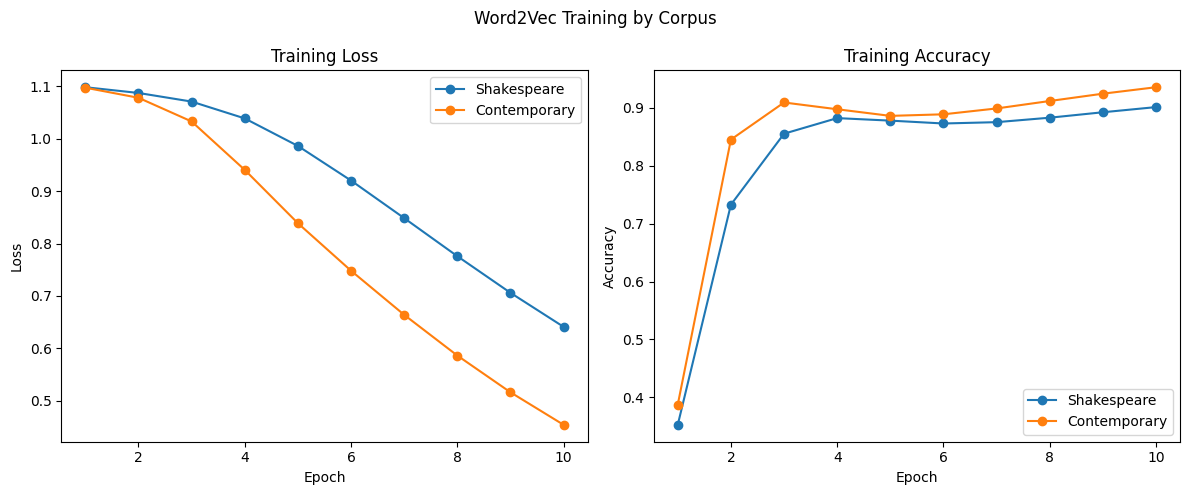

In [10]:
import matplotlib.pyplot as plt

def plot_training_comparison(results_by_name):
    fig = plt.figure(figsize=(12, 5))
    ax_loss, ax_acc = fig.subplots(1, 2)

    for name, results in results_by_name.items():
        history = results["history"].history
        loss = history.get("loss", [])
        accuracy = history.get("accuracy", [])

        epochs = range(1, len(loss) + 1)

        ax_loss.plot(epochs, loss, marker="o", label=name)
        ax_acc.plot(epochs, accuracy, marker="o", label=name)

    ax_loss.set_title("Training Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    ax_acc.set_title("Training Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

    fig.suptitle("Word2Vec Training by Corpus")
    fig.tight_layout()
    plt.show()

plot_training_comparison({
    "Shakespeare": shakespeare_results,
    "Contemporary": contemporary_results,
})

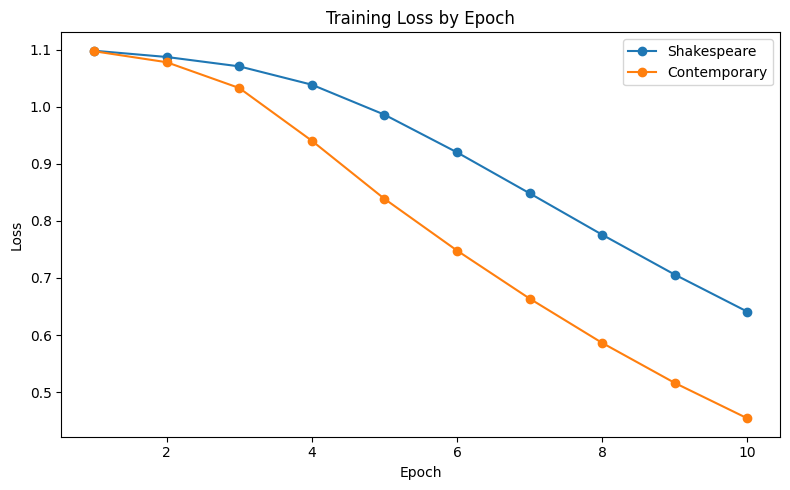

In [11]:
import matplotlib.pyplot as plt

def plot_loss_by_epoch(results_by_name):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.subplots(1, 1)

    for name, results in results_by_name.items():
        loss = results["history"].history.get("loss", [])
        epochs = range(1, len(loss) + 1)
        ax.plot(epochs, loss, marker="o", label=name)

    ax.set_title("Training Loss by Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_loss_by_epoch({
    "Shakespeare": shakespeare_results,
    "Contemporary": contemporary_results,
})

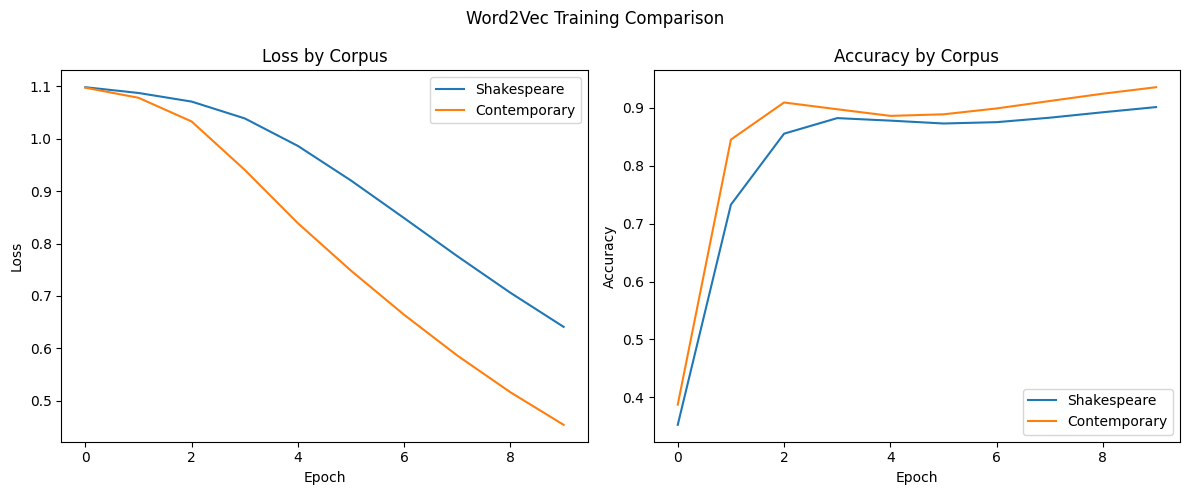

In [12]:
import matplotlib.pyplot as plt

def plot_training_comparison(results_by_name):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    for name, results in results_by_name.items():
        history = results["history"].history
        ax[0].plot(history["loss"], label=name)
        ax[1].plot(history["accuracy"], label=name)

    ax[0].set_title("Loss by Corpus")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].set_title("Accuracy by Corpus")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    fig.suptitle("Word2Vec Training Comparison")
    plt.tight_layout()
    plt.show()

plot_training_comparison({
    "Shakespeare": shakespeare_results,
    "Contemporary": contemporary_results,
})

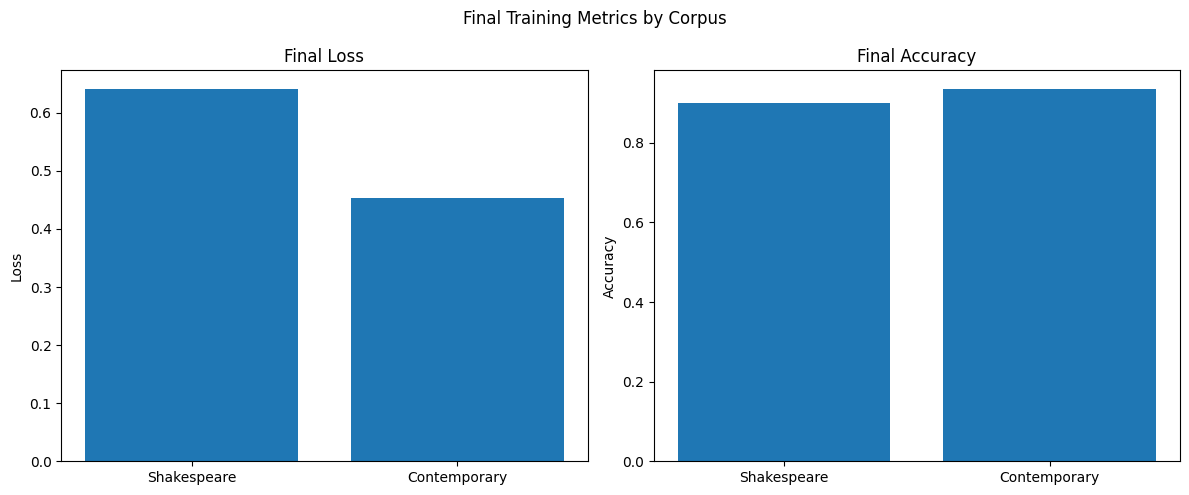

In [13]:
def plot_final_metrics(results_by_name):
    names = []
    final_losses = []
    final_accuracies = []

    for name, results in results_by_name.items():
        history = results["history"].history
        names.append(name)
        final_losses.append(history["loss"][-1])
        final_accuracies.append(history["accuracy"][-1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(names, final_losses)
    axes[0].set_title("Final Loss")
    axes[0].set_ylabel("Loss")

    axes[1].bar(names, final_accuracies)
    axes[1].set_title("Final Accuracy")
    axes[1].set_ylabel("Accuracy")

    fig.suptitle("Final Training Metrics by Corpus")
    plt.tight_layout()
    plt.show()

plot_final_metrics(results_by_name)

In [14]:

def get_nearest_neighbors(results, query_word, top_k=5):
    vocab = results["vocab"]
    weights = results["weights"]

    if query_word not in vocab:
        return []

    word_index = vocab.index(query_word)
    query_vector = weights[word_index]

    norms = np.linalg.norm(weights, axis=1, keepdims=True)
    normalized_weights = weights / np.clip(norms, 1e-12, None)

    query_norm = np.linalg.norm(query_vector)
    query_vector = query_vector / max(query_norm, 1e-12)

    scores = normalized_weights @ query_vector
    nearest_indices = np.argsort(scores)[::-1]

    neighbors = []
    for index in nearest_indices:
        candidate = vocab[index]
        if candidate == query_word:
            continue
        if candidate in ("", "[UNK]"):
            continue
        neighbors.append((candidate, float(scores[index])))
        if len(neighbors) == top_k:
            break

    return neighbors

In [15]:
# use king, love, man, woman, day, or time 
query_word = "king"

for name, results in results_by_name.items():
    neighbors = get_nearest_neighbors(results, query_word=query_word, top_k=8)
    print(f"\n{name} neighbors for '{query_word}':")
    for word, score in neighbors:
        print(f"{word:15s} {score:.4f}")


Shakespeare neighbors for 'king':
second          0.5713
wonderd         0.5703
prodigal        0.5517
piece           0.5452
infant          0.5421
mouse           0.5416
calm            0.5410
bastard         0.5355

Contemporary neighbors for 'king':
bob             0.7179
overnight       0.7062
washed          0.6936
on,             0.6910
j.              0.6875
feels           0.6873
mcafee          0.6872
google's        0.6840


# Classification Task on Movie Reviews

In [16]:
# Movie review classification comparison using pretrained embeddings
from pathlib import Path
import tarfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Map corpus names to config so each embedding uses its own token standardization
config_by_name = {
    "Shakespeare": shakespeare_config,
    "Contemporary": contemporary_config,
}

def load_imdb_raw_datasets(seed=42):
    imdb_cache_dir = Path.cwd() / ".tf_data"
    imdb_cache_dir.mkdir(parents=True, exist_ok=True)

    dataset_archive = Path(tf.keras.utils.get_file(
        fname="aclImdb_v1.tar.gz",
        origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
        cache_dir=str(imdb_cache_dir),
        cache_subdir="",
        extract=False,
    ))

    dataset_dir = imdb_cache_dir / "aclImdb"
    if not dataset_dir.exists():
        with tarfile.open(dataset_archive, "r:gz") as tar:
            tar.extractall(path=imdb_cache_dir)

    if not dataset_dir.exists():
        raise FileNotFoundError(f"IMDB dataset directory not found after extraction: {dataset_dir}")

    train_dir = dataset_dir / "train"
    test_dir = dataset_dir / "test"

    print(f"Dataset archive: {dataset_archive}")
    print(f"Dataset directory: {dataset_dir}")

    def make_labeled_review_ds(split_dir, shuffle=False):
        if not split_dir.exists():
            raise FileNotFoundError(f"Split directory does not exist: {split_dir}")
        
        pos_files = sorted((split_dir / "pos").glob("*.txt"))
        neg_files = sorted((split_dir / "neg").glob("*.txt"))
        file_paths = [str(p) for p in pos_files + neg_files]
        labels = [1] * len(pos_files) + [0] * len(neg_files)

        if not file_paths:
            raise ValueError(
                f"No review files found under {split_dir}. Expected pos/*.txt and neg/*.txt."
            )

        ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
        if shuffle and len(file_paths) > 1:
            ds = ds.shuffle(len(file_paths), seed=seed, reshuffle_each_iteration=False)

        ds = ds.map(
            lambda path, label: (tf.io.read_file(path), tf.cast(label, tf.float32)),
            num_parallel_calls=AUTOTUNE
        )
        return ds

    full_train_ds = make_labeled_review_ds(train_dir, shuffle=True)
    test_ds = make_labeled_review_ds(test_dir, shuffle=False)

    val_size = 5000
    val_ds = full_train_ds.take(val_size)
    train_ds = full_train_ds.skip(val_size)

    batch_size = 64
    train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(AUTOTUNE)
    test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)
    return train_ds, val_ds, test_ds

def build_classifier_from_embedding(results, cfg, sequence_length=200, trainable=False):
    vocab = results["vocab"]
    weights = results["weights"]

    print(f"Using pretrained embedding matrix shape: {weights.shape}")
    print(f"Using pretrained vocabulary size: {len(vocab)}")

    standardize = build_standardizer(
        lowercase=cfg.lowercase,
        strip_punctuation=cfg.strip_punctuation,
        keep_apostrophes=cfg.keep_apostrophes,
    )

    review_vectorizer = layers.TextVectorization(
        standardize=standardize,
        output_mode="int",
        output_sequence_length=sequence_length,
        vocabulary=vocab,
    )

    model = tf.keras.Sequential([
        review_vectorizer,
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=weights.shape[1],
            embeddings_initializer=tf.keras.initializers.Constant(weights),
            trainable=trainable,
            mask_zero=True,
            name="pretrained_embedding",
        ),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

def evaluate_binary(model, test_ds, threshold=0.5):
    y_true_batches, y_prob_batches = [], []
    for x_batch, y_batch in test_ds:
        y_prob = model.predict(x_batch, verbose=0).reshape(-1)
        y_true_batches.append(y_batch.numpy().reshape(-1))
        y_prob_batches.append(y_prob)

    y_true = np.concatenate(y_true_batches).astype(np.int32)
    y_prob = np.concatenate(y_prob_batches)
    y_pred = (y_prob >= threshold).astype(np.int32)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    eps = 1e-8
    accuracy = (tp + tn) / max(len(y_true), 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, eps)

    auc_metric = tf.keras.metrics.AUC()
    auc_metric.update_state(y_true, y_prob)
    auc = float(auc_metric.result().numpy())

    return {
        "y_true": y_true,
        "y_prob": y_prob,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": auc,
    }

def best_threshold_by_f1(y_true, y_prob, thresholds=np.arange(0.1, 0.91, 0.05)):
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int32)
        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        tn = int(np.sum((y_true == 0) & (y_pred == 0)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-8)
        accuracy = (tp + tn) / max(len(y_true), 1)
        rows.append((float(t), float(accuracy), float(precision), float(recall), float(f1)))
    return max(rows, key=lambda x: x[4]), rows


Dataset archive: /content/.tf_data/aclImdb_v1.tar.gz
Dataset directory: /content/.tf_data/aclImdb

Training classifier with Shakespeare embeddings
Using pretrained embedding matrix shape: (4096, 128)
Using pretrained vocabulary size: 4096
Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5371 - auc: 0.5518 - loss: 0.6902 - val_accuracy: 0.5440 - val_auc: 0.5981 - val_loss: 0.6879
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5638 - auc: 0.5887 - loss: 0.6838 - val_accuracy: 0.5726 - val_auc: 0.6180 - val_loss: 0.6808
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5818 - auc: 0.6117 - loss: 0.6775 - val_accuracy: 0.5864 - val_auc: 0.6413 - val_loss: 0.6738
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5957 - auc: 0.6314 - loss: 0.6708 - val_accuracy: 0.6016 - val_auc: 0.6554 - val_loss: 0.6658
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6037 - auc: 0.6452 - loss: 0.6649 - val_accuracy: 0.610

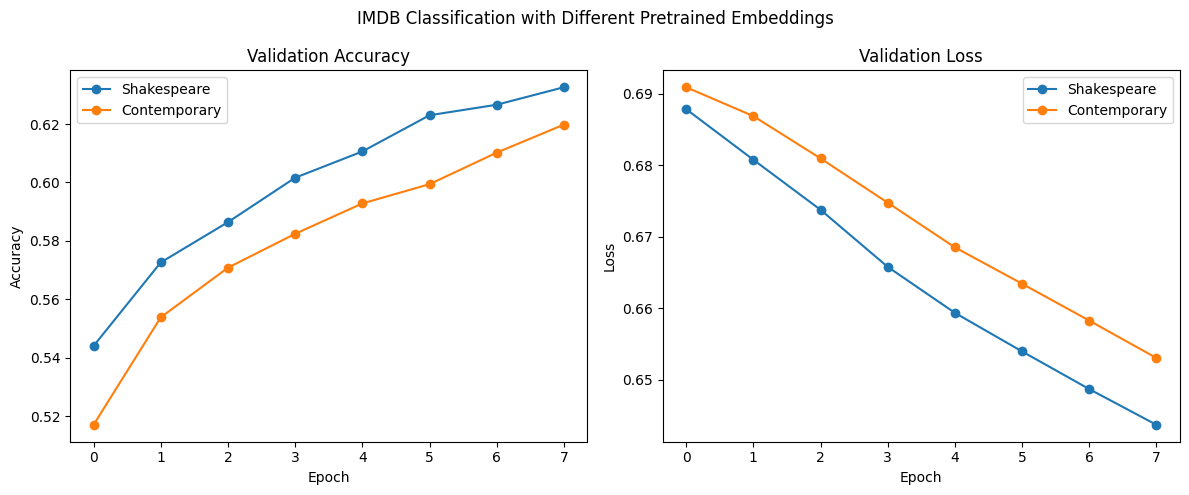

In [17]:

train_ds, val_ds, test_ds = load_imdb_raw_datasets(seed=SEED)

classification_results = {}
summary_rows = []

for name, w2v_results in results_by_name.items():
    print("\n" + "=" * 72)
    print(f"Training classifier with {name} embeddings")

    model = build_classifier_from_embedding(
        results=w2v_results,
        cfg=config_by_name[name],
        sequence_length=200,
        trainable=False,  # keep frozen for clean embedding-quality comparison
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
    eval_stats = evaluate_binary(model, test_ds, threshold=0.5)
    best_t, _ = best_threshold_by_f1(eval_stats["y_true"], eval_stats["y_prob"])

    classification_results[name] = {
        "model": model,
        "history": history,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "test_auc": float(test_auc),
        "eval": eval_stats,
        "best_threshold": best_t[0],
        "best_f1": best_t[4],
    }

    summary_rows.append((
        name,
        float(test_acc),
        float(test_auc),
        eval_stats["precision"],
        eval_stats["recall"],
        eval_stats["f1"],
        float(best_t[0]),
        float(best_t[4]),
    ))

print("\nComparison Summary")
print("name         test_acc  test_auc  precision  recall   f1@0.5   best_thr  best_f1")
print("-" * 88)
for r in summary_rows:
    print(f"{r[0]:12s} {r[1]:8.4f} {r[2]:8.4f} {r[3]:9.4f} {r[4]:8.4f} {r[5]:8.4f} {r[6]:8.2f} {r[7]:8.4f}")

# Validation curves comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, payload in classification_results.items():
    h = payload["history"].history
    axes[0].plot(h.get("val_accuracy", []), marker="o", label=name)
    axes[1].plot(h.get("val_loss", []), marker="o", label=name)

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

fig.suptitle("IMDB Classification with Different Pretrained Embeddings")
plt.tight_layout()
plt.show()

# Class Refactor with Config

## Config & Utils

In [18]:
## Classification Config & Utilities

from dataclasses import dataclass

@dataclass
class ClassificationConfig:
    """Configuration for movie review classification task."""
    sequence_length: int = 200
    trainable_embedding: bool = False
    dense_units: int = 64
    dropout_rate: float = 0.3
    batch_size: int = 64
    epochs: int = 8
    early_stopping_patience: int = 2
    threshold: float = 0.5
    val_split: int = 5000  # number of examples to use for validation
    seed: int = 42

def make_labeled_review_ds(config, split_dir, shuffle=False):
    seed = config.seed
    
    if not split_dir.exists():
        raise FileNotFoundError(f"Split directory does not exist: {split_dir}")
    
    pos_files = sorted((split_dir / "pos").glob("*.txt"))
    neg_files = sorted((split_dir / "neg").glob("*.txt"))
    file_paths = [str(p) for p in pos_files + neg_files]
    labels = [1] * len(pos_files) + [0] * len(neg_files)

    if not file_paths:
        raise ValueError(
            f"No review files found under {split_dir}. Expected pos/*.txt and neg/*.txt."
        )

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle and len(file_paths) > 1:
        ds = ds.shuffle(len(file_paths), seed=seed, reshuffle_each_iteration=False)

    ds = ds.map(
        lambda path, label: (tf.io.read_file(path), tf.cast(label, tf.float32)),
        num_parallel_calls=AUTOTUNE
    )
    return ds

def load_imdb_raw_datasets(config):
    """Load and prepare IMDB train/val/test splits."""
    batch_size = config.batch_size

    # Constants for IMDB dataset
    IMDB_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    IMDB_CACHE_SUBDIR = ".tf_data"
    imdb_cache_dir = Path.cwd() / IMDB_CACHE_SUBDIR
    imdb_cache_dir.mkdir(parents=True, exist_ok=True)

    dataset_archive = Path(tf.keras.utils.get_file(
        fname="aclImdb_v1.tar.gz",
        origin=IMDB_URL,
        cache_dir=str(imdb_cache_dir),
        cache_subdir="",
        extract=False,
    ))

    dataset_dir = imdb_cache_dir / "aclImdb"
    if not dataset_dir.exists():
        with tarfile.open(dataset_archive, "r:gz") as tar:
            tar.extractall(path=imdb_cache_dir)

    if not dataset_dir.exists():
        raise FileNotFoundError(f"IMDB dataset directory not found after extraction: {dataset_dir}")

    train_dir = dataset_dir / "train"
    test_dir = dataset_dir / "test"

    full_train_ds = make_labeled_review_ds(config, train_dir, shuffle=True)
    test_ds = make_labeled_review_ds(config, test_dir, shuffle=False)

    val_size = config.val_split
    val_ds = full_train_ds.take(val_size)
    train_ds = full_train_ds.skip(val_size)

    train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(AUTOTUNE)
    test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)
    
    return train_ds, val_ds, test_ds


def build_classifier_from_embedding(results, cfg, config):
    """Build classification model using pretrained embeddings."""
    vocab = results["vocab"]
    weights = results["weights"]

    standardize = build_standardizer(
        lowercase=cfg.lowercase,
        strip_punctuation=cfg.strip_punctuation,
        keep_apostrophes=cfg.keep_apostrophes,
    )

    review_vectorizer = layers.TextVectorization(
        standardize=standardize,
        output_mode="int",
        output_sequence_length=config.sequence_length,
        vocabulary=vocab,
    )

    model = tf.keras.Sequential([
        review_vectorizer,
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=weights.shape[1],
            embeddings_initializer=tf.keras.initializers.Constant(weights),
            trainable=config.trainable_embedding,
            mask_zero=True,
            name="pretrained_embedding",
        ),
        layers.GlobalAveragePooling1D(),
        layers.Dense(config.dense_units, activation="relu"),
        layers.Dropout(config.dropout_rate),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model


def evaluate_binary(model, test_ds, threshold=0.5):
    """Compute confusion matrix and metrics."""
    y_true_batches, y_prob_batches = [], []
    for x_batch, y_batch in test_ds:
        y_prob = model.predict(x_batch, verbose=0).reshape(-1)
        y_true_batches.append(y_batch.numpy().reshape(-1))
        y_prob_batches.append(y_prob)

    y_true = np.concatenate(y_true_batches).astype(np.int32)
    y_prob = np.concatenate(y_prob_batches)
    y_pred = (y_prob >= threshold).astype(np.int32)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    eps = 1e-8
    accuracy = (tp + tn) / max(len(y_true), 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, eps)

    auc_metric = tf.keras.metrics.AUC()
    auc_metric.update_state(y_true, y_prob)
    auc = float(auc_metric.result().numpy())

    return {
        "y_true": y_true,
        "y_prob": y_prob,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": auc,
    }


def best_threshold_by_f1(y_true, y_prob, thresholds=np.arange(0.1, 0.91, 0.05)):
    """Sweep thresholds and return best by F1."""
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int32)
        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        tn = int(np.sum((y_true == 0) & (y_pred == 0)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-8)
        accuracy = (tp + tn) / max(len(y_true), 1)
        rows.append((float(t), float(accuracy), float(precision), float(recall), float(f1)))
    return max(rows, key=lambda x: x[4]), rows


def train_classification_pipeline(results_by_name, config_by_name, imdb_datasets, clf_config):
    """
    Train classifiers using multiple embeddings on shared IMDB data.
    
    Args:
        results_by_name: dict keyed by corpus name -> word2vec results dict
        config_by_name: dict keyed by corpus name -> CorpusConfig
        imdb_datasets: tuple of (train_ds, val_ds, test_ds)
        clf_config: ClassificationConfig instance
    
    Returns:
        dict keyed by corpus name -> classification results dict
    """
    train_ds, val_ds, test_ds = imdb_datasets
    classification_results = {}
    summary_rows = []

    for name, w2v_results in results_by_name.items():
        print("\n" + "=" * 72)
        print(f"Training classifier with {name} embeddings")
        print("=" * 72)

        model = build_classifier_from_embedding(
            results=w2v_results,
            cfg=config_by_name[name],
            config=clf_config,
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=clf_config.early_stopping_patience,
                restore_best_weights=True
            )
        ]

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=clf_config.epochs,
            callbacks=callbacks,
            verbose=1
        )

        test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
        eval_stats = evaluate_binary(model, test_ds, threshold=clf_config.threshold)
        best_t, threshold_sweep = best_threshold_by_f1(eval_stats["y_true"], eval_stats["y_prob"])

        classification_results[name] = {
            "model": model,
            "history": history,
            "test_loss": float(test_loss),
            "test_acc": float(test_acc),
            "test_auc": float(test_auc),
            "eval": eval_stats,
            "threshold_sweep": threshold_sweep,
            "best_threshold": best_t[0],
            "best_f1": best_t[4],
        }

        summary_rows.append((
            name,
            float(test_acc),
            float(test_auc),
            eval_stats["precision"],
            eval_stats["recall"],
            eval_stats["f1"],
            float(best_t[0]),
            float(best_t[4]),
        ))

    return classification_results, summary_rows

## Train

In [20]:
## Train Classifiers (this runs the pipeline)

classification_config = ClassificationConfig(
    epochs=10,
)

# Load IMDB dataset once
train_ds, val_ds, test_ds = load_imdb_raw_datasets(classification_config)
print(f"Dataset loaded: train {len(train_ds)} batches, val {len(val_ds)}, test {len(test_ds)}")

# Run full classification pipeline
classification_results, summary_rows = train_classification_pipeline(
    results_by_name=results_by_name,
    config_by_name=config_by_name,
    imdb_datasets=(train_ds, val_ds, test_ds),
    clf_config=classification_config,
)

# Save summary
print("\n" + "=" * 88)
print("CLASSIFICATION COMPARISON SUMMARY")
print("=" * 88)
print("name         test_acc  test_auc  precision  recall   f1@0.5   best_thr  best_f1")
print("-" * 88)
for r in summary_rows:
    print(f"{r[0]:12s} {r[1]:8.4f} {r[2]:8.4f} {r[3]:9.4f} {r[4]:8.4f} {r[5]:8.4f} {r[6]:8.2f} {r[7]:8.4f}")

Dataset loaded: train 313 batches, val 79, test 391

Training classifier with Shakespeare embeddings
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5306 - auc: 0.5462 - loss: 0.6907 - val_accuracy: 0.5324 - val_auc: 0.5974 - val_loss: 0.6891
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5624 - auc: 0.5845 - loss: 0.6847 - val_accuracy: 0.5746 - val_auc: 0.6142 - val_loss: 0.6821
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5811 - auc: 0.6083 - loss: 0.6784 - val_accuracy: 0.5852 - val_auc: 0.6357 - val_loss: 0.6755
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5892 - auc: 0.6251 - loss: 0.6723 - val_accuracy: 0.5954 - val_auc: 0.6534 - val_loss: 0.6678
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6036 - auc: 0.6417 - loss: 0.6661 - val_accuracy: 0.6098 - val_auc: 0.6658 - val_loss: 0.6609
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6164 - auc: 0.6551 - loss: 

## Evaluation & Plots

In [25]:

def run_predict_and_analyze_threshold(model):
  threshold = 0.5
  uncertainty_margin = 0.10  # 0.40 to 0.60 is treated as uncertain

  sample_reviews = tf.constant([
      "this movie was excellent and emotionally engaging",
      "the plot was dull and the acting was terrible",
      "it started slowly but became quite moving by the end",
  ])

  probs = model.predict(sample_reviews, verbose=0).flatten()

  print("\nSample Predictions with Confidence Analysis")
  print(f"Note: Threshold for positive classification is {threshold:.2f}")
  print("-" * 95)
  print("prob_pos | prob_neg | pred_label | confidence | review")
  print("-" * 95)

  for review, p in zip(sample_reviews.numpy(), probs):
      p = float(p)
      pred_label = "positive" if p >= threshold else "negative"

      # Confidence bucket based on distance from 0.5
      distance = abs(p - 0.5)
      if distance >= 0.40:
          confidence = "very high"
      elif distance >= 0.25:
          confidence = "high"
      elif distance >= 0.10:
          confidence = "medium"
      else:
          confidence = "low/uncertain"

      # Optional explicit uncertainty zone
      uncertain = (threshold - uncertainty_margin) <= p <= (threshold + uncertainty_margin)
      uncertainty_flag = " (uncertain)" if uncertain else ""

      print(f"{p:7.3f} | {1-p:8.3f} | {pred_label:10s} | {confidence:12s} | {review.decode('utf-8')}{uncertainty_flag}")

def analyze_sample_predictions(classification_results):
    for name, results in classification_results.items():
        print("\n" + "=" * 72)
        print(f"Analyzing predictions for {name} embeddings")
        print("=" * 72)
        model = results["model"]
        run_predict_and_analyze_threshold(model)

analyze_sample_predictions(classification_results)


Analyzing predictions for Shakespeare embeddings

Sample Predictions with Confidence Analysis
Note: Threshold for positive classification is 0.50
-----------------------------------------------------------------------------------------------
prob_pos | prob_neg | pred_label | confidence | review
-----------------------------------------------------------------------------------------------
  0.618 |    0.382 | positive   | medium       | this movie was excellent and emotionally engaging
  0.441 |    0.559 | negative   | low/uncertain | the plot was dull and the acting was terrible (uncertain)
  0.555 |    0.445 | positive   | low/uncertain | it started slowly but became quite moving by the end (uncertain)

Analyzing predictions for Contemporary embeddings

Sample Predictions with Confidence Analysis
Note: Threshold for positive classification is 0.50
-----------------------------------------------------------------------------------------------
prob_pos | prob_neg | pred_label | confi

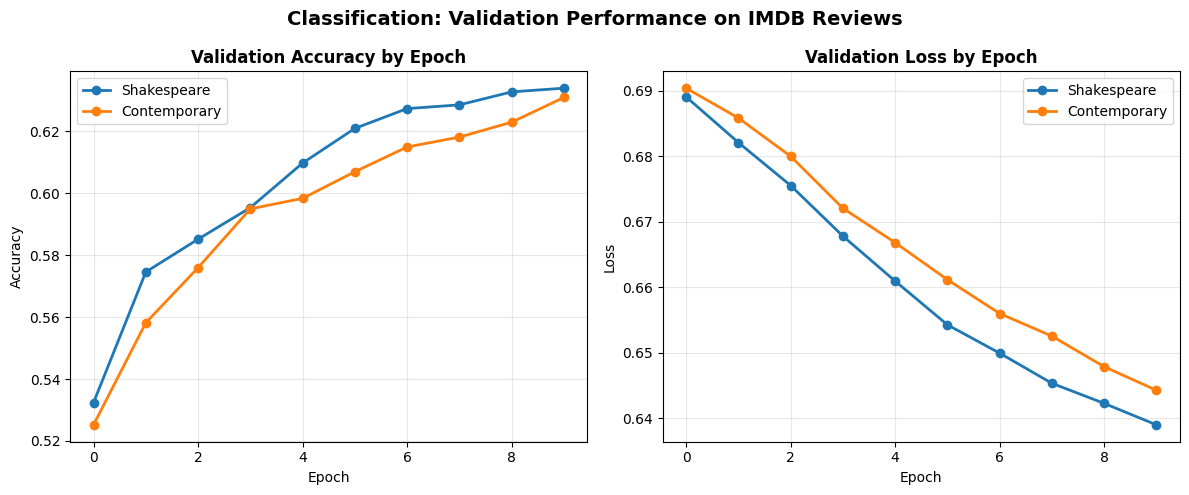

In [23]:
## Plot Validation Curves

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, payload in classification_results.items():
    h = payload["history"].history
    axes[0].plot(h.get("val_accuracy", []), marker="o", label=name, linewidth=2)
    axes[1].plot(h.get("val_loss", []), marker="o", label=name, linewidth=2)

axes[0].set_title("Validation Accuracy by Epoch", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation Loss by Epoch", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Classification: Validation Performance on IMDB Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

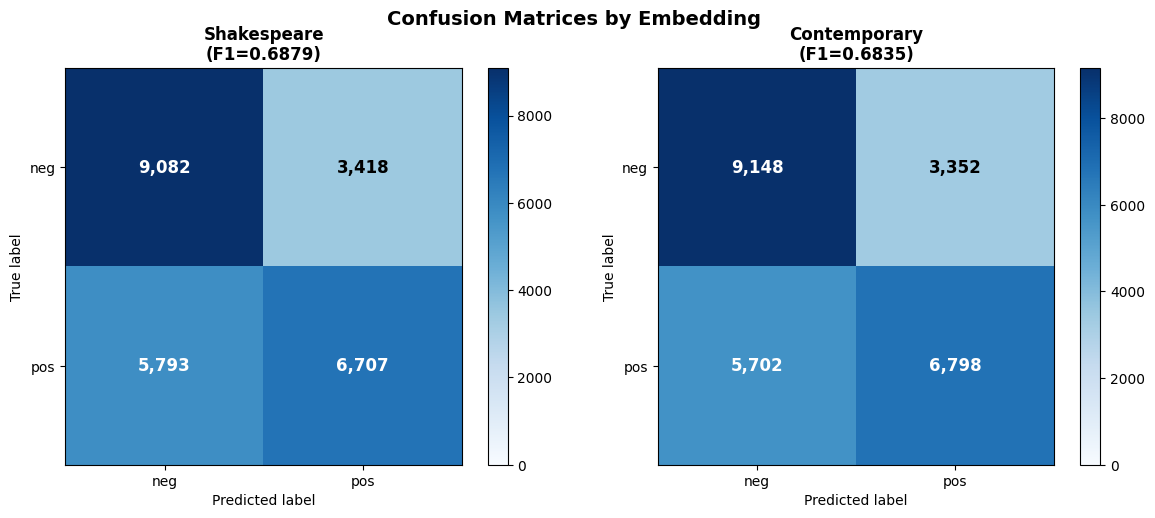

In [21]:
## Plot Confusion Matrices Side-by-Side

fig, axes = plt.subplots(1, len(classification_results), figsize=(6 * len(classification_results), 5))
if len(classification_results) == 1:
    axes = [axes]

for idx, (name, payload) in enumerate(classification_results.items()):
    eval_stats = payload["eval"]
    tp, tn, fp, fn = eval_stats["tp"], eval_stats["tn"], eval_stats["fp"], eval_stats["fn"]
    
    cm = np.array([[tn, fp], [fn, tp]])
    ax = axes[idx]
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_title(f"{name}\n(F1={payload['best_f1']:.4f})", fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["neg", "pos"])
    ax.set_yticklabels(["neg", "pos"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", 
                   color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12, fontweight="bold")

    fig.colorbar(im, ax=ax)

fig.suptitle("Confusion Matrices by Embedding", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

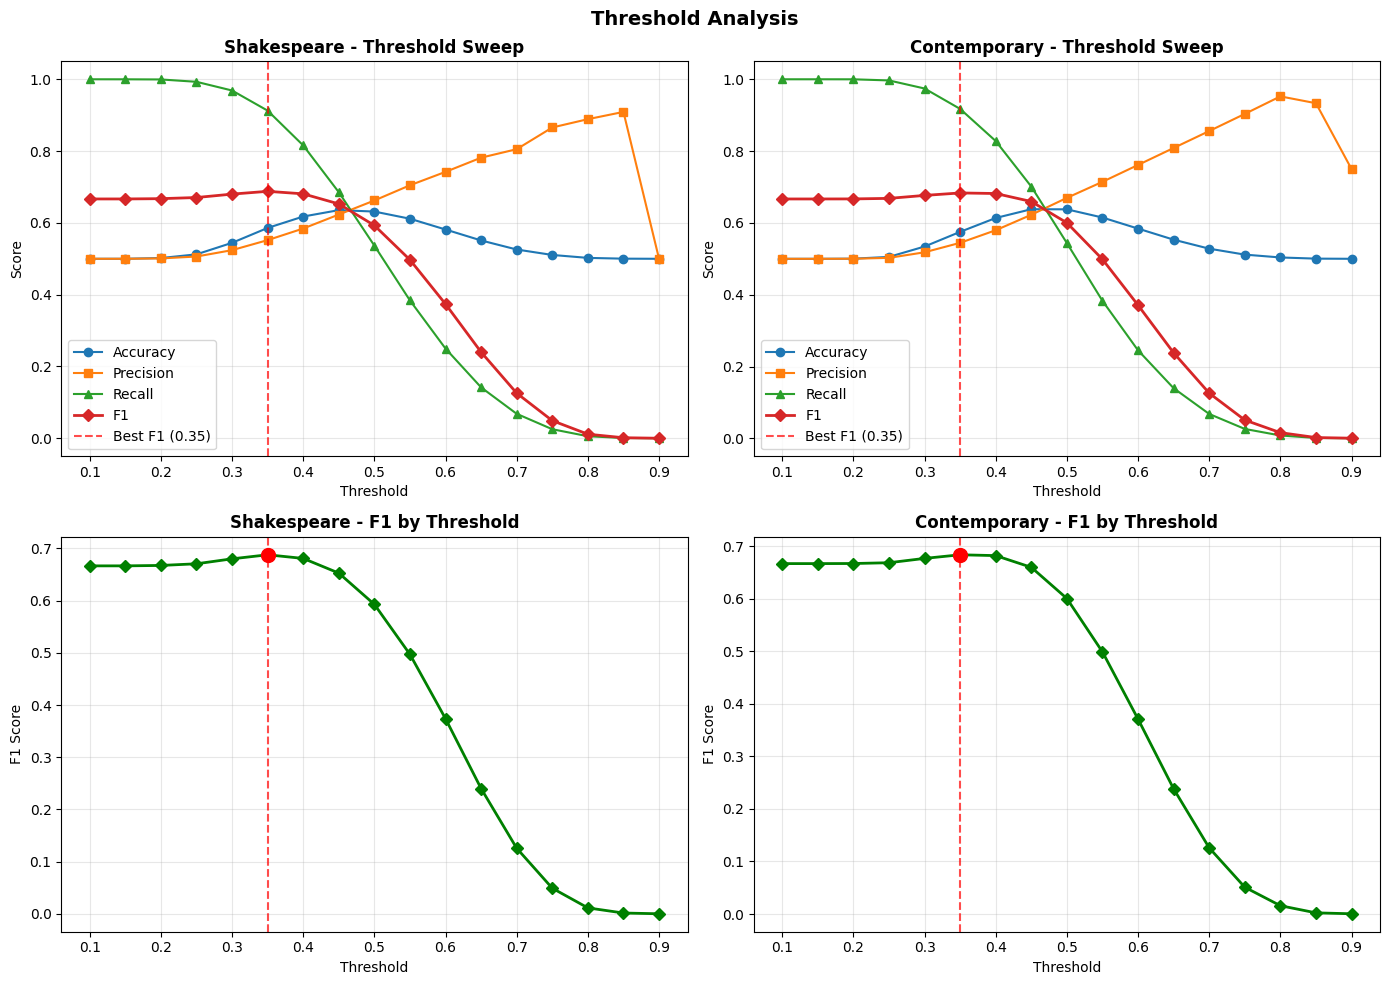

In [22]:
## Plot Threshold Sweep & Metrics

fig, axes = plt.subplots(2, len(classification_results), figsize=(7 * len(classification_results), 10))
if len(classification_results) == 1:
    axes = axes.reshape(2, 1)

for idx, (name, payload) in enumerate(classification_results.items()):
    threshold_sweep = payload["threshold_sweep"]
    thresholds = [t[0] for t in threshold_sweep]
    
    # Parse metrics
    accuracies = [t[1] for t in threshold_sweep]
    precisions = [t[2] for t in threshold_sweep]
    recalls = [t[3] for t in threshold_sweep]
    f1s = [t[4] for t in threshold_sweep]
    
    # Top plot: all metrics
    ax = axes[0, idx]
    ax.plot(thresholds, accuracies, marker="o", label="Accuracy")
    ax.plot(thresholds, precisions, marker="s", label="Precision")
    ax.plot(thresholds, recalls, marker="^", label="Recall")
    ax.plot(thresholds, f1s, marker="D", label="F1", linewidth=2)
    ax.axvline(x=payload["best_threshold"], color="red", linestyle="--", alpha=0.7, label=f"Best F1 ({payload['best_threshold']:.2f})")
    ax.set_title(f"{name} - Threshold Sweep", fontweight="bold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Bottom plot: F1 only
    ax = axes[1, idx]
    ax.plot(thresholds, f1s, marker="D", linewidth=2, color="green")
    ax.axvline(x=payload["best_threshold"], color="red", linestyle="--", alpha=0.7)
    ax.scatter(x=[payload["best_threshold"]], y=[payload["best_f1"]], color="red", s=100, zorder=5)
    ax.set_title(f"{name} - F1 by Threshold", fontweight="bold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F1 Score")
    ax.grid(True, alpha=0.3)

fig.suptitle("Threshold Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def binary_entropy_bits(p_pos, eps=1e-12):
    # Clip to avoid log(0)
    p = np.clip(np.asarray(p_pos, dtype=float), eps, 1 - eps)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

rows = []
entropy_by_model = {}

for name, payload in classification_results.items():
    y_prob = payload["eval"]["y_prob"]  # test-set P(positive)
    H = binary_entropy_bits(y_prob)     # per-sample entropy in bits, range [0, 1]
    entropy_by_model[name] = H

    rows.append({
        "model": name,
        "n_samples": len(H),
        "mean_entropy_bits": float(H.mean()),
        "median_entropy_bits": float(np.median(H)),
        "p90_entropy_bits": float(np.percentile(H, 90)),
        "low_conf_rate_H_gt_0.90": float(np.mean(H > 0.90)),  # very uncertain
        "high_conf_rate_H_lt_0.30": float(np.mean(H < 0.30)), # confident
    })

summary = pd.DataFrame(rows).sort_values("mean_entropy_bits")
display(summary)

# Plot entropy distributions
n = len(entropy_by_model)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, (name, H) in zip(axes, entropy_by_model.items()):
    ax.hist(H, bins=30, alpha=0.8)
    ax.axvline(H.mean(), linestyle="--", linewidth=2, label=f"mean={H.mean():.3f}")
    ax.set_title(f"{name} entropy (bits)")
    ax.set_xlabel("Entropy H")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Prediction Uncertainty Distribution (Test Set)")
plt.tight_layout()
plt.show()

# Run inline and pipeline again with Reset Seeds

This compares deltas to confirm variance is due to natural uncertainty in the data or faulty plumbing and keeping hyperparameters the same.

In [24]:
import random
import numpy as np
import tensorflow as tf

def reset_everything(seed=42, deterministic_ops=True):
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    if deterministic_ops:
        try:
            tf.config.experimental.enable_op_determinism()
        except Exception:
            pass

# Inline-style builder matching your earlier non-config version
def build_classifier_inline(results, cfg, sequence_length=200, trainable=False):
    vocab = results["vocab"]
    weights = results["weights"]

    standardize = build_standardizer(
        lowercase=cfg.lowercase,
        strip_punctuation=cfg.strip_punctuation,
        keep_apostrophes=cfg.keep_apostrophes,
    )

    review_vectorizer = layers.TextVectorization(
        standardize=standardize,
        output_mode="int",
        output_sequence_length=sequence_length,
        vocabulary=vocab,
    )

    model = tf.keras.Sequential([
        review_vectorizer,
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=weights.shape[1],
            embeddings_initializer=tf.keras.initializers.Constant(weights),
            trainable=trainable,
            mask_zero=True,
            name="pretrained_embedding",
        ),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

def train_inline_loop(results_by_name, config_by_name, imdb_datasets, epochs=8, threshold=0.5):
    train_ds, val_ds, test_ds = imdb_datasets
    out = {}

    for name, w2v_results in results_by_name.items():
        model = build_classifier_inline(
            results=w2v_results,
            cfg=config_by_name[name],
            sequence_length=200,
            trainable=False,
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True,
            )
        ]

        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=callbacks,
            verbose=0,
        )

        test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
        out[name] = {
            "test_loss": float(test_loss),
            "test_acc": float(test_acc),
            "test_auc": float(test_auc),
        }

    return out

def summarize_runs(run_records):
    # run_records: dict[name][path] -> list of accuracies
    print("\nMean ± std over seeds (accuracy)")
    print("-" * 72)
    print(f'{"Corpus":14s} {"Inline":20s} {"Refactor":20s} {"Delta(ref-inline)":16s}')
    print("-" * 72)

    for name in run_records:
        inline_vals = np.array(run_records[name]["inline"], dtype=float)
        ref_vals = np.array(run_records[name]["refactor"], dtype=float)
        delta = ref_vals - inline_vals

        inline_str = f"{inline_vals.mean():.4f} ± {inline_vals.std(ddof=1):.4f}"
        ref_str = f"{ref_vals.mean():.4f} ± {ref_vals.std(ddof=1):.4f}"
        delta_str = f"{delta.mean():+.4f} ± {delta.std(ddof=1):.4f}"
        print(f"{name:14s} {inline_str:20s} {ref_str:20s} {delta_str:16s}")

# ---- experiment settings ----
seeds = [42, 43, 44, 45, 46]
compare_epochs = 8   # set 8 for apples-to-apples with old loop
deterministic_ops = True

run_records = {
    name: {"inline": [], "refactor": []}
    for name in results_by_name.keys()
}

for seed in seeds:
    print(f"\nRunning seed={seed}")

    # Build one shared split for both methods at this seed
    reset_everything(seed=seed, deterministic_ops=deterministic_ops)
    cfg = ClassificationConfig(
        sequence_length=200,
        trainable_embedding=False,
        dense_units=64,
        dropout_rate=0.3,
        batch_size=64,
        epochs=compare_epochs,
        early_stopping_patience=2,
        threshold=0.5,
        val_split=5000,
        seed=seed,
    )
    train_ds, val_ds, test_ds = load_imdb_raw_datasets(cfg)
    shared_datasets = (train_ds, val_ds, test_ds)

    # Inline path
    reset_everything(seed=seed, deterministic_ops=deterministic_ops)
    inline_out = train_inline_loop(
        results_by_name=results_by_name,
        config_by_name=config_by_name,
        imdb_datasets=shared_datasets,
        epochs=compare_epochs,
        threshold=0.5,
    )

    # Refactor path
    reset_everything(seed=seed, deterministic_ops=deterministic_ops)
    ref_out, _ = train_classification_pipeline(
        results_by_name=results_by_name,
        config_by_name=config_by_name,
        imdb_datasets=shared_datasets,
        clf_config=cfg,
    )

    # Collect test accuracy
    for name in results_by_name.keys():
        run_records[name]["inline"].append(inline_out[name]["test_acc"])
        run_records[name]["refactor"].append(ref_out[name]["test_acc"])

summarize_runs(run_records)


Running seed=42

Training classifier with Shakespeare embeddings
Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5327 - auc: 0.5467 - loss: 0.6911 - val_accuracy: 0.5498 - val_auc: 0.5970 - val_loss: 0.6890
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5653 - auc: 0.5843 - loss: 0.6858 - val_accuracy: 0.5610 - val_auc: 0.6119 - val_loss: 0.6842
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5774 - auc: 0.6035 - loss: 0.6803 - val_accuracy: 0.5826 - val_auc: 0.6299 - val_loss: 0.6771
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5877 - auc: 0.6210 - loss: 0.6743 - val_accuracy: 0.5930 - val_auc: 0.6499 - val_loss: 0.6702
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5982 - auc: 0.6374 - loss: 0.6682 - val_accuracy: 0.6100 - val_auc: 0.6634 - val_loss: 0.6628
Epoch 6/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6096 - auc: 0.6486 - loss: 0.6632 - val_accuracy: 0.6164 - val_auc: 